# OpenTRIM "1 MeV H in Fe" example

This notebook shows how to run the "1 MeV H in Fe" example from OpenTRIM's GUI using Python.

Basic steps:
- JSON configuration is prepared in Python and saved to a file
- `opentrim` command-line executable is called with the JSON input
- HDF5 output file is opened with `h5py`
- Data plots are created with `matplotlib`

It is assumed that `opentrim` is available on your `PATH`. If it is not, set `exe` to the full path (example in the comment below).

## 1. Load required Python modules

In [63]:
from pathlib import Path   # convenient, cross-platform path handling (files, joining paths, etc.)
import json                # encode/decode JSON (opentrim -t output, writing config.json)

import subprocess          # run the external `opentrim` executable and capture stdout/stderr
import tempfile            # create a temporary directory to run opentrim without polluting your repo

from typing import Any, Dict  # type hints for config dictionaries, helps readability in notebooks

import h5py                # read the HDF5 output file produced by opentrim (result.h5)
import numpy as np         # convert datasets to NumPy arrays, manipulate/flatten/slice for plotting
import matplotlib.pyplot as plt  # plot results from datasets using Matplotlib

# 2. Generate the standard json configuration template.

Using OpenTRIM's `-t` CLI option

In [64]:
exe = "opentrim"           # replace with full path if necessary, e.g. "/home/[user]/bin/opentrim" 
cmd = [exe, "-t"]

template_run = subprocess.run(
    cmd,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    timeout=20,
)

template_run.check_returncode()  # raises if opentrim -t failed

# Convert json to Dict
Config: Dict[str, Any] = json.loads(template_run.stdout)

## 3. Edit the configuration

Main options for "1 MeV H in Fe" example:
- Ion beam: 1 MeV H$^+$ (default - no change needed)
- Target material: Fe (default - no change needed) 
- Target size: 10 μm square
- Flight path: "Variable" (for max efficiency)

In [65]:
# Set target size 10μm = 10000 nm
Config["Target"]["size"] = [
            10000.0,
            10000.0,
            10000.0
        ]
# 100 cells along the beam path (x-axis)
Config["Target"]["cell_count"] = [
            100,
            1,
            1
        ]
# Single Fe region covers the whole simulation box
Config["Target"]["regions"][0]["size"] = [
            10000.0,
            10000.0,
            10000.0
        ]
# H beam enters at the center of the front face
Config["IonBeam"]["spatial_distribution"]["center"] = [
                0.0,
                5000.0,
                5000.0]

# set flight path type:
Config["Transport"]["flight_path_type"] = "Variable"

# Set title
Config["Output"]["title"] = "1 MeV H on Fe example"

# Run option
Config["Run"]["threads"] = 0    # 0 means: OpenTRIM selects no. of threads depending on hardware
Config["Run"]["max_no_ions"] = 20000 # simulated ions


## 4. Run `opentrim` in a temp folder

In [66]:
tmpdir = tempfile.TemporaryDirectory(prefix="opentrim_")
tmppath = Path(tmpdir.name);

config_path = tmppath / "config.json"
config_path.write_text(json.dumps(Config, indent=4) + "\n", encoding="utf-8")

cmd = [exe, "-f", "config.json", "-o", "result", "-s", "42"]
result = subprocess.run(
    cmd,
    cwd=tmppath,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    stdin=subprocess.DEVNULL,
    timeout=120,
)

print("returncode:", result.returncode)
if result.returncode:
    print("stderr:\n", result.stderr)
else:
    print("stdout:\n", result.stdout)


returncode: 0
stdout:
 Parsing JSON config from config.json
Starting simulation '1 MeV H on Fe example'...


║                                        ║  0%║ETC 00:00:00║
║█████████████████▊                      ║ 44%║ETC 00:00:01║
║██████████████████████████████████▋     ║ 86%║ETC 00:00:01║
║████████████████████████████████████████║100%║ETC 00:00:00║
║████████████████████████████████████████║100%║ETC 00:00:00║

Completed 20000 ion histories.
Threads: 4
CPU time (s):  1.84926,	Ions/cpu-s:  10815.1
Wall time (s): 0.50096,	Ions/wall-s: 39923.3
Storing results in result.h5 ... OK.



## 5. Read data from HDF5 output file

Open using `h5py` and read some datasets into `numpy` arrays

In [67]:
h5_path = tmppath / "result.h5"
if not h5_path.exists():
    raise FileNotFoundError(f"Expected output file not found: {h5_path}")

with h5py.File(h5_path, "r") as f:
    # Read datasets
    # x-axis grid points
    x = np.asarray(f["/target/grid/X"][0:100])  # shape (101,)
    # Fe vacancies
    v = np.asarray(f["/tally/damage_events/Vacancies"][1, 0:100, 0, 0])
    # Fe atomic density nm^-3, convert to cm^-3
    Nfe = f["/target/materials/atomic_density"][()]*1e21

## 6. Plot displacement damage profile

Convert OpenTRIM vacancy/ion data to dpa/ion flux and plot the damage profile.

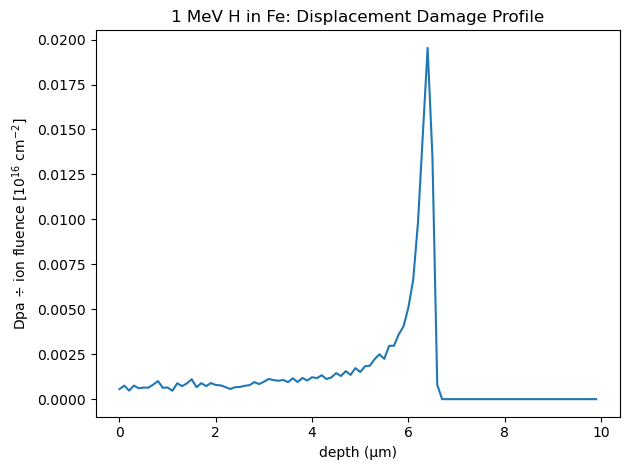

In [68]:
# Convert vacancies/ion to dpa/10^16 ions/cm^2
F0 = 1e16;  # ion flux
dx = (x[1]-x[0])*1e-7 # x grid step in cm 

# Plot
plt.figure()
plt.plot(x*1e-3, v*(F0/dx/Nfe))
plt.xlabel("depth (μm)")
plt.ylabel(r"Dpa $\div$ ion fluence [10$^{16}$ cm$^{-2}$]")
plt.title("1 MeV H in Fe: Displacement Damage Profile")
plt.tight_layout()
plt.show()